### Objective
Develop and validate an interpretable stroke risk prediction model using logistic regression.  
Focus is on:
- Discrimination (ROC-AUC, PR-AUC)
- Calibration (Brier score, calibration slope)
- Interpretability (odds ratios + confidence intervals)
- Risk stratification for clinical decision support

### Why Logistic Regression?
- Transparent
- Odds ratios are clinically interpretable
- Suitable for risk scoring
- Easier calibration than tree models

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix, classification_report
import statsmodels.api as sm
from sklearn.base import clone

### Data Loading  
Training and Test sets are loaded from parquet files prepared from the EDA.  
Target variable = Stroke (Binary outcome)

In [28]:
train_df = pd.read_parquet(r'C:\Users\oluwa\OneDrive\Documents\Data Science_ML\Stroke Risk Prediction\Stroke Risk\train_df.parquet')
train_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_missing
0,25283,Female,48.0,0,0,Yes,Private,Urban,69.21,33.1,Never smoked,0,0
1,41917,Female,29.0,0,0,No,Private,Urban,84.19,21.2,Never smoked,0,0
2,36045,Female,35.0,0,0,Yes,Private,Rural,119.40,22.9,Never smoked,0,0
3,28315,Male,38.0,0,0,Yes,Private,Rural,108.68,32.7,Never smoked,0,0
4,26325,Male,14.0,0,0,No,Government Job,Urban,82.34,31.6,Unknown,0,0


In [29]:
test_df = pd.read_parquet(r'C:\Users\oluwa\OneDrive\Documents\Data Science_ML\Stroke Risk Prediction\Stroke Risk\test_df.parquet')
test_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_missing
0,3777,Female,28.0,1,0,Yes,Government Job,Rural,83.66,36.4,Never smoked,0,0
1,8277,Female,3.0,0,0,No,Not working,Urban,93.30,19.5,Unknown,0,0
2,58282,Female,53.0,0,0,Yes,Government Job,Rural,64.40,31.0,Smokes,0,0
3,46488,Male,35.0,0,0,Yes,Private,Rural,69.22,42.8,Never smoked,0,0
4,8831,Female,58.0,0,0,Yes,Private,Rural,94.30,29.1,Unknown,0,0


In [30]:
X_train = train_df.drop(columns = ['id','stroke'])
y_train = train_df['stroke']

X_test = test_df.drop(columns = ['id','stroke'])
y_test = test_df['stroke']

### Preprocessing
Numerical features:  
Standardized using StandardScaler to ensure comparable scale and stable regularized optimization.

Categorical features:  
Encoded using OneHotEncoder with drop='first' to prevent perfect multicollinearity.

Missing values:  
Missing values were present only in the bmi feature. These were imputed during EDA using an age- and gender-informed strategy to preserve distributional structure and reduce bias.

In [31]:
cat_vars = ['gender','ever_married', 'work_type', 'residence_type','smoking_status']
num_vars = ['age', 'avg_glucose_level', 'bmi', 'bmi_missing', 'hypertension', 'heart_disease']

### Model Training and Hyperparameter Tuning with GridSearchCV
A Logistic Regression model with L2 regularization was trained using a full preprocessing pipeline to prevent data leakage. Hyperparameter tuning (for the regularization strength (C)) was performed using GridSearchCV with 5-fold stratified cross-validation.  

#### Evaluation Metric: PR-AUC (Average Precision)

PR-AUC was selected as the optimization metric because stroke is a relatively rare outcome in the dataset, with a prevalence of 4.9%. Optimizing PR-AUC ensures the model prioritizes correct identification of stroke cases rather than overall classification accuracy.  
The best model achieved a PR-AUC score of 0.2298, a substantial ≈ 4.7x improvement over random prediction.

In [32]:
num_pipeline = Pipeline([('scaler', StandardScaler())])
cat_pipeline = Pipeline([('encoder', OneHotEncoder(handle_unknown= 'ignore', drop = 'first'))])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_vars), 
    ('cat', cat_pipeline, cat_vars)
])

lr = LogisticRegression(penalty = 'l2', max_iter = 1000, solver = 'lbfgs')

full_pipeline = Pipeline([('preprocessor', preprocessor),
               ('model', lr)])

param_grid = {'model__C':[0.001, 0.01, 0.1, 1, 10, 100]}

cv = StratifiedKFold(n_splits = 5, shuffle  = True, random_state = 42)

grid = GridSearchCV(full_pipeline, param_grid = param_grid, cv = cv, scoring = 'average_precision', n_jobs  = -1)

grid.fit(X_train, y_train)


print("Best C:", grid.best_params_)
print("Best CV PR-AUC:", grid.best_score_)

best_model = grid.best_estimator_

Best C: {'model__C': 1}
Best CV PR-AUC: 0.22983681087607236


c:\Users\oluwa\miniconda3\envs\biostat\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### Cross-validation performance
The logistic regression model was evaluated using 5-fold stratified cross-validation to obtain robust performance metrics.  

A **ROC-AUC** of **0.853** indicates strong overall discrimination. The model can correctly rank a randomly selected stroke case higher than a non-stroke case approximately 85% of the time.  

The **PR-AUC** of **0.230** is still substantially higher than the baseline prevalence (0.049) representing ~4–5× improvement over random prediction.  

The **Brier score** of **0.042** indicates good overall probability calibration.  


In [33]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import brier_score_loss, make_scorer, average_precision_score, roc_auc_score

scoring = {
    'roc_auc' : 'roc_auc',
    'pr_auc' : 'average_precision',
    'brier' : 'neg_brier_score'
}

cv_results = cross_validate(
    best_model, X_train, y_train, 
    cv = cv, scoring = scoring, n_jobs = -1
)

print("ROC-AUC: {:.3f} ± {:.3f}".format(
    np.mean(cv_results['test_roc_auc']),
    np.std(cv_results['test_roc_auc'])
))

print("PR-AUC: {:.3f} ± {:.3f}".format(
    np.mean(cv_results['test_pr_auc']),
    np.std(cv_results['test_pr_auc'])
))

print("Brier: {:.3f} ± {:.3f}".format(
    -np.mean(cv_results['test_brier']),
    np.std(cv_results['test_brier'])
))

ROC-AUC: 0.853 ± 0.027
PR-AUC: 0.230 ± 0.045
Brier: 0.042 ± 0.001


### Evaluating model on Test set
The model performed well on unseen data across all three metrics of ROC-AUC, PR-AUC and Brier score, indicating good generalization.

In [35]:
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_test_proba))
print("Test Brier:", brier_score_loss(y_test, y_test_proba))

Test ROC-AUC: 0.8367901234567902
Test PR-AUC: 0.21896619144322116
Test Brier: 0.04184853196299857


### Calibration Assessment
The points lie close to the 45° reference line, indicating good agreement between predicted probabilities and observed stroke incidence. Most predictions are concentrated in the low-probability region (< 0.20), which is expected given the 4.9% prevalence.

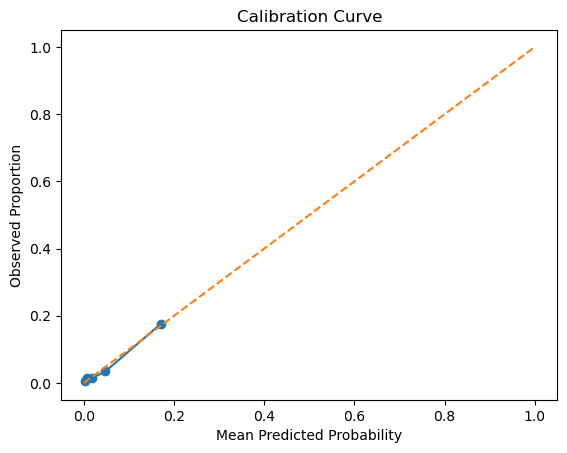

In [36]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_proba,
    n_bins=5,
    strategy='quantile'
)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Proportion")
plt.title("Calibration Curve")
plt.show()

### Model Coefficients and Odd Ratios
An OR > 1 indicates increased stroke risk; OR < 1 indicates reduced risk relative to the reference category.

**Age is the dominant predictor by a wide margin** — a 1 SD increase in age multiplies stroke odds by ~5×.  

**Missing BMI:** Missing BMI ranks as the 2nd strongest positive predictor (OR = 1.34), likely reflecting that sicker or older patients were more likely to have BMI unrecorded.  

**Average glucose level** and **Hypertension** are also notable predictors of Stroke risk

**Negative Predictors:** Variables such as ever married and self-employed show slightly negative coefficients after controlling for age. This likely reflects age confounding and should not be interpreted as protective in a clinical sense. Never smoked and having an unknown smoking status (likely to be younger individuals) also show slightly negative coeffiencients for stroke risk

In [37]:
log_reg = best_model.named_steps['model']

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

coefficients = log_reg.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
})

coef_df.sort_values("odds_ratio", ascending= False)

,feature,coefficient,odds_ratio
0,num__age,1.616315,5.034506
3,num__bmi_missing,0.290742,1.337420
1,num__avg_glucose_level,0.166311,1.180941
4,num__hypertension,0.134379,1.143827
11,cat__residence_type_Urban,0.075537,1.078463
2,num__bmi,0.067571,1.069906
9,cat__work_type_Private,0.060551,1.062421
8,cat__work_type_Not working,0.056553,1.058183
6,cat__gender_Male,0.036019,1.036676
13,cat__smoking_status_Smokes,0.035795,1.036443


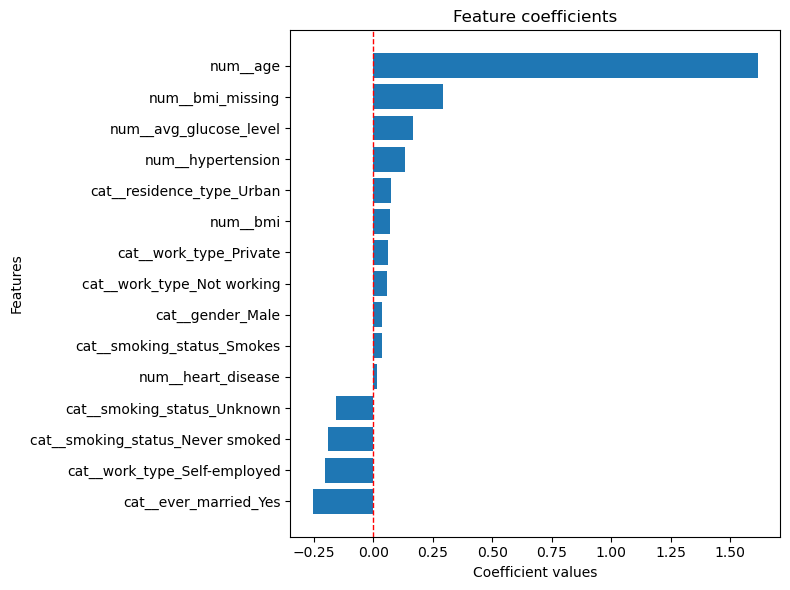

In [38]:
coef_sorted = coef_df.sort_values("coefficient", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(coef_sorted['feature'], coef_sorted['coefficient'])
plt.xlabel('Coefficient values')
plt.ylabel('Features')
plt.title('Feature coefficients')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

### Refitting model using StatsModels
The logistic regression model was refitted using StatsModels to obtain statistical inference (p-values and confidence intervals). Predictors with p < 0.05 and confidence intervals not crossing 1 are considered statistically significant.  

In this model, the significant predictors are:
- Age (OR = 5.24, 95% CI: 3.92–7.01, p < 0.001)
- Average Glucose Level (OR = 1.18, 95% CI: 1.05–1.33, p = 0.006)
- BMI Missing Indicator (OR = 1.34, 95% CI: 1.23–1.46, p < 0.001)
- Hypertension (OR = 1.14, 95% CI: 1.03–1.27, p = 0.015)

Most other predictors have confidence intervals crossing 1 and non-significant p-values, indicating limited independent contribution once the major risk factors are included.

In [39]:
X_transformed = best_model.named_steps['preprocessor'].transform(X_train)

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

X_sm = pd.DataFrame(X_transformed, columns = feature_names)

X_sm = sm.add_constant(X_sm)

y_sm = y_train.reset_index(drop=True)

In [40]:
logit_model = sm.Logit(y_sm, X_sm)
result = logit_model.fit()

summary_df = pd.DataFrame({
    "feature": result.params.index,
    "coefficient": result.params.values,
    "odds_ratio": np.exp(result.params.values),
    "CI_lower": np.exp(result.conf_int()[0]),
    "CI_upper": np.exp(result.conf_int()[1]),
    "p_value": result.pvalues
})

summary_df

Optimization terminated successfully.
         Current function value: 0.150479
         Iterations 10


,feature,coefficient,odds_ratio,CI_lower,CI_upper,p_value
const,const,-3.828861,0.021734,0.010568,0.044700,2.295389e-25
num__age,num__age,1.657147,5.244328,3.921836,7.012782,5.273447e-29
num__avg_glucose_level,num__avg_glucose_level,0.165413,1.179880,1.047455,1.329048,6.464038e-03
num__bmi,num__bmi,0.076062,1.079030,0.886017,1.314088,4.493884e-01
num__bmi_missing,num__bmi_missing,0.291777,1.338805,1.225797,1.462231,8.882047e-11
num__hypertension,num__hypertension,0.133322,1.142618,1.026575,1.271778,1.468851e-02
num__heart_disease,num__heart_disease,0.013890,1.013987,0.918219,1.119744,7.837692e-01
cat__gender_Male,cat__gender_Male,0.033537,1.034105,0.753895,1.418466,8.352422e-01
cat__ever_married_Yes,cat__ever_married_Yes,-0.297388,0.742756,0.452115,1.220233,2.403456e-01
cat__work_type_Not working,cat__work_type_Not working,0.344212,1.410878,0.158319,12.573173,7.577560e-01


### Coefficient Stability Across Cross-Validation Folds
To assess the robustness of model coefficients, the logistic regression model was retrained across the 5 cross-validation folds. Coefficients from each fold were extracted and their mean and standard deviation were computed.  
Key clinical predictors such as **age**, **average glucose level**, **hypertension**, and the **BMI missing indicator** show very low coefficient variability, indicating that their associations with stroke risk remain consistent across folds.  
Several categorical variables exhibit relatively higher variability, particularly **work type** categories and **smoking status**, suggesting that their estimated effects are less stable and may depend on the specific sample used for training. This likely reflects smaller subgroup sizes or weaker predictive signals for these variables.

In [41]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

coef_matrix = []

for train_idx, val_idx in skf.split(X_train, y_train):
    
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    
    model = clone(best_model)
    model.fit(X_tr, y_tr)
    
    coef_matrix.append(
        model.named_steps['model'].coef_[0]
    )

coef_matrix = np.array(coef_matrix)

coef_stability = pd.DataFrame({
    "feature": feature_names,
    "mean_coef": coef_matrix.mean(axis=0),
    "std_coef": coef_matrix.std(axis=0)
})

coef_stability.sort_values("std_coef", ascending=False)

c:\Users\oluwa\miniconda3\envs\biostat\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\oluwa\miniconda3\envs\biostat\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\oluwa\miniconda3\envs\biostat\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.1

,feature,mean_coef,std_coef
8,cat__work_type_Not working,0.058261,0.314794
13,cat__smoking_status_Smokes,0.037672,0.138459
10,cat__work_type_Self-employed,-0.206815,0.113382
14,cat__smoking_status_Unknown,-0.166043,0.109687
9,cat__work_type_Private,0.051057,0.084659
11,cat__residence_type_Urban,0.070811,0.082377
2,num__bmi,0.064976,0.066251
6,cat__gender_Male,0.031179,0.062251
0,num__age,1.605573,0.057763
7,cat__ever_married_Yes,-0.270793,0.056693


### Threshold Optimization

The default classification threshold of **0.5** is poorly suited to imbalanced datasets. In this dataset, stroke prevalence is low, and a threshold of 0.5 makes the model overly conservative, resulting in the majority of true stroke cases being missed.

To address this, the decision threshold was selected using **cross-validated probability estimates (5-fold CV)** rather than predictions from a single model fit. This approach reduces the risk of optimistic bias and ensures the threshold reflects out-of-sample model behaviour.

Rather than optimising for F1 score, the threshold was selected to achieve a **minimum recall of 0.80**, ensuring that at least **80% of true stroke cases are identified**, while maximising precision among thresholds that satisfy this recall constraint.

> **Clinical rationale:** Missing a stroke patient carries greater clinical risk than unnecessarily evaluating a low-risk individual. Therefore, the model prioritises sensitivity (recall) to minimise missed cases, accepting reduced precision as a trade-off.

Using this threshold, the model correctly identifies **160 of 199 stroke patients (recall = 0.80)** while missing **39 cases**. However, this sensitivity comes at the cost of **947 false positives**, resulting in a **precision of 0.14**, meaning approximately **1 in 7 flagged individuals is a true stroke case**.

This trade-off reflects the typical behaviour of screening-oriented predictive models in low-prevalence clinical settings:

- **39 missed stroke patients (False Negatives)** – individuals not flagged by the model
- **947 over-flagged patients (False Positives)** – individuals requiring unnecessary clinical review

Despite the increase in false positives, this strategy substantially reduces the number of missed stroke cases compared with a default 0.5 threshold.

In [42]:
from sklearn.model_selection import cross_val_predict

y_proba = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)[:, 1]

c:\Users\oluwa\miniconda3\envs\biostat\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\oluwa\miniconda3\envs\biostat\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\oluwa\miniconda3\envs\biostat\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.1

In [43]:
precision, recall, thresholds = precision_recall_curve(y_train, y_proba)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

threshold_df["f1"] = 2 * (
    threshold_df["precision"] * threshold_df["recall"]
) / (
    threshold_df["precision"] + threshold_df["recall"]
)

threshold_df.sort_values("f1", ascending=False).head()

,threshold,precision,recall,f1
3713,0.147043,0.221925,0.417085,0.289703
3712,0.146823,0.221333,0.417085,0.289199
3684,0.140734,0.215881,0.437186,0.289037
3711,0.146582,0.220745,0.417085,0.288696
3683,0.140350,0.215347,0.437186,0.288557


In [44]:
# Setting threshold based on highest F1 score

best_thresh = threshold_df.loc[
    threshold_df["f1"].idxmax(),
    "threshold"
]

In [45]:
y_pred = (y_proba >= best_thresh).astype(int)

print(confusion_matrix(y_train, y_pred))
print(classification_report(y_train, y_pred))

[[3597  291]
 [ 116   83]]
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      3888
           1       0.22      0.42      0.29       199

    accuracy                           0.90      4087
   macro avg       0.60      0.67      0.62      4087
weighted avg       0.93      0.90      0.91      4087



In [46]:
# Adjusting threshold to achieve recall of 0.80
target_recall = 0.80

candidate = threshold_df[threshold_df["recall"] >= target_recall]

best_thresh = candidate.sort_values("precision", ascending=False).iloc[0]["threshold"]

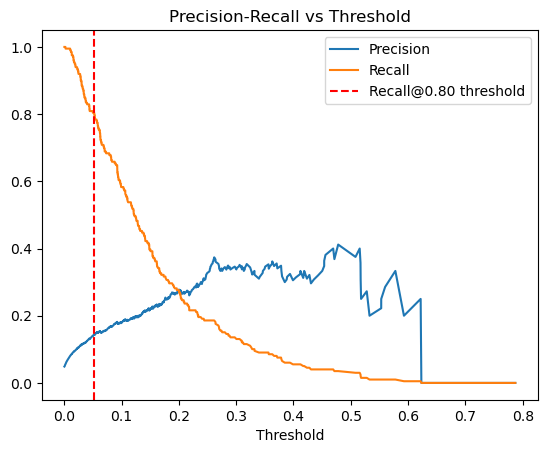

In [47]:
# Plotting precision-recall tradeoff to find the inflection point visually
import matplotlib.pyplot as plt

plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.axvline(x=best_thresh, color='red', linestyle='--', label="Recall@0.80 threshold")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision-Recall vs Threshold")
plt.show()

In [48]:
y_pred = (y_proba >= best_thresh).astype(int)

print(confusion_matrix(y_train, y_pred))
print(classification_report(y_train, y_pred))

[[2941  947]
 [  39  160]]
              precision    recall  f1-score   support

           0       0.99      0.76      0.86      3888
           1       0.14      0.80      0.25       199

    accuracy                           0.76      4087
   macro avg       0.57      0.78      0.55      4087
weighted avg       0.95      0.76      0.83      4087



### High-Risk Threshold

To further stratify patients, a **High-risk tier** was defined using a **minimum precision requirement of 0.30**.

Precision represents the proportion of individuals predicted to be high risk who truly experience stroke. By requiring **precision ≥ 0.30**, the model ensures that **at least 1 in 3 individuals classified as high risk are true stroke cases**.

This threshold was chosen to create a subgroup with **substantially elevated stroke probability**, making the High-risk category more clinically meaningful and suitable for intensified monitoring or preventive interventions.

In [49]:
low_cutoff = best_thresh
high_cutoff = threshold_df[
    threshold_df["precision"] >= 0.30
].sort_values("precision").iloc[0]["threshold"]

def assign_risk_tier(prob):
    if prob >= high_cutoff:
        return "High"
    elif prob >= low_cutoff:
        return "Moderate"
    else:
        return "Low"

risk_tiers = pd.Series(y_proba).apply(assign_risk_tier)
print(risk_tiers.value_counts())

Low         2980
Moderate     977
High         130
Name: count, dtype: int64


### Risk Stratification Performance

To evaluate the clinical usefulness of the model, predicted probabilities were stratified into **Low**, **Moderate**, and **High** risk tiers using the previously defined probability thresholds.

These results demonstrate clear risk stratification across the three tiers:

- Individuals in the **High-risk tier** have an observed stroke rate of **30%**, meaning approximately **1 in 3 individuals** in this category experienced stroke.
- The **Moderate-risk tier** shows an intermediate stroke rate of **12.4%**, indicating elevated risk compared with the general population.
- The **Low-risk tier** has a stroke rate of **1.3%**, suggesting a substantially lower probability of stroke.

The model therefore produces a **strong gradient of risk**, with stroke probability increasing progressively from Low → Moderate → High tiers.

In relative terms, individuals classified as **High risk have approximately 23 times the stroke probability of those in the Low-risk group**. This level of separation suggests that the model is effective at identifying subgroups with meaningfully different stroke risk profiles, which is essential for clinical risk stratification and targeted preventive intervention.

In [50]:
tier_df = pd.DataFrame(
    {"prob" : y_proba,
    "true" : y_train}
)

tier_df['tier'] = tier_df['prob'].apply(assign_risk_tier)

tier_df.groupby("tier")["true"].agg(["mean", "count"]).sort_values(by='mean', ascending= False)

,mean,count
tier,,
High,0.300000,130
Moderate,0.123849,977
Low,0.013087,2980


### Risk Stratification on the Test Set

To evaluate the generalisability of the risk stratification scheme, the trained model was applied to the held-out test set. Predicted probabilities were converted into **Low**, **Moderate**, and **High** risk tiers using the same probability thresholds derived from the training data.

Individuals in the **High-risk tier have approximately 18 times the stroke probability of those in the Low-risk tier**.  

The similarity between the training and test set tier outcomes suggests that the probability thresholds used for risk stratification generalise reasonably well to unseen data.

In [52]:
test_tier_df = pd.DataFrame({
    'prob':y_test_proba,
    'true': y_test
})

test_tier_df['tier'] = test_tier_df['prob'].apply(assign_risk_tier)

tier_results = test_tier_df.groupby('tier')['true'].agg(["mean", "count"]).sort_values(by = 'mean', ascending=False)
tier_results

,mean,count
tier,,
High,0.242424,33
Moderate,0.131148,244
Low,0.013423,745


In [53]:
### Saving fitted model
import joblib

joblib.dump(best_model, "stroke_model.pkl")

['stroke_model.pkl']